# CORDIS Funding by Country — Example Solution

This notebook is the **reference solution** to the *Your Turn* exercise in `geopandas.ipynb`.
It maps EU research funding across European countries using CORDIS organisation data and a Europe shapefile.

## Contents
1. Load & explore the CORDIS data
2. Extract country codes & aggregate funding
3. Load the Europe shapefile
4. Merge funding data onto the map
5. Basic choropleth — total funding
6. Annotated map with funding amounts
7. Number of organisations per country
8. Side-by-side: funding vs. number of orgs
9. Adjustable label positions

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

import sys
sys.path.insert(0, '..')
from template import setup_matplotlib_template, get_colors, get_cmap

# Apply TG house style
setup_matplotlib_template('TG')
TG_COLORS = get_colors('TG')
tg_cmap = get_cmap('TG')

Century Gothic font loaded successfully from resources folder
Finlandica font loaded successfully
Make sure that you have the Finlandica font installed on your system by double/right clicking the .ttf file and press install.


---
## 1. Load & Explore the CORDIS Data

Each row in `cordis_orgs.csv` is one organisation's participation in one EU project.

In [ ]:
df_all = pd.read_csv('../assets/cordis_orgs.csv')

print(f"Full dataset — rows: {len(df_all):,}  projects: {df_all['projectID'].nunique():,}  orgs: {df_all['organisationID'].nunique():,}")
print(f"\nTop master calls:")
print(df_all['masterCall'].value_counts().head(10).to_string())
df_all.head(3)

---
## 2. Extract Country Codes & Aggregate Funding

The first 2 letters of `vatNumber` encode the country (e.g. `FR`, `DE`, `ES`).
We filter to a single master call, then sum funding per country.

In [16]:
# Filter to a single master call
MASTER_CALL = 'HORIZON-CL5-2022-D2-01'
df = df_all[df_all['masterCall'] == MASTER_CALL].copy()
df

,projectID,organisationID,vatNumber,name,shortName,ecContribution,netEcContribution,totalCost,masterCall,subCall,fundingScheme
55304,101103821,912743326,ESB98896137,LOMARTOV SL,LOMARTOV APPLIED INNOVATION ENGINEERING,174250.00,174250.00,174250,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
55305,101103821,984232326,ESG78216819,ASOCIACION ESPANOLA DE NORMALIZACION,UNE,85737.50,85737.50,"85737,5",HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
55306,101103821,999584128,ATU14703506,AIT AUSTRIAN INSTITUTE OF TECHNOLOGY GMBH,AIT,710177.25,710177.25,"710177,25",HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
55307,101103821,999902094,BE0449012406,VRIJE UNIVERSITEIT BRUSSEL,VUB,428500.00,428500.00,428500,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
55308,101103821,984450188,DE174051125,ACCUREC-RECYCLING GMBH,AC,306250.00,306250.00,306250,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
...,...,...,...,...,...,...,...,...,...,...,...
121718,101103706,885436274,EL996687200,FRONTIER KENTRO KAINOTOMIAS AMKE,NaN,0.00,187468.75,0,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
121719,101103706,897707744,ESB67513630,EIT KIC URBAN MOBILITY SL,NaN,62351.25,62351.25,"62351,25",HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
121720,101103706,897528779,FR76850572231,TES SUSTAINABLE BATTERY SOLUTION FRANCE,TES SBS France,736500.00,736500.00,736500,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA
121721,101103706,928030235,ESG66210345,FUNDACIO EURECAT,EURECAT,910305.00,910305.00,910305,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA


In [17]:
# Extract 2-letter country code from VAT number
df['country'] = df['vatNumber'].str.extract(r'^([A-Z]{2})')
df

,projectID,organisationID,vatNumber,name,shortName,ecContribution,netEcContribution,totalCost,masterCall,subCall,fundingScheme,country
55304,101103821,912743326,ESB98896137,LOMARTOV SL,LOMARTOV APPLIED INNOVATION ENGINEERING,174250.00,174250.00,174250,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,ES
55305,101103821,984232326,ESG78216819,ASOCIACION ESPANOLA DE NORMALIZACION,UNE,85737.50,85737.50,"85737,5",HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,ES
55306,101103821,999584128,ATU14703506,AIT AUSTRIAN INSTITUTE OF TECHNOLOGY GMBH,AIT,710177.25,710177.25,"710177,25",HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,AT
55307,101103821,999902094,BE0449012406,VRIJE UNIVERSITEIT BRUSSEL,VUB,428500.00,428500.00,428500,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,BE
55308,101103821,984450188,DE174051125,ACCUREC-RECYCLING GMBH,AC,306250.00,306250.00,306250,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,DE
...,...,...,...,...,...,...,...,...,...,...,...,...
121718,101103706,885436274,EL996687200,FRONTIER KENTRO KAINOTOMIAS AMKE,NaN,0.00,187468.75,0,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,EL
121719,101103706,897707744,ESB67513630,EIT KIC URBAN MOBILITY SL,NaN,62351.25,62351.25,"62351,25",HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,ES
121720,101103706,897528779,FR76850572231,TES SUSTAINABLE BATTERY SOLUTION FRANCE,TES SBS France,736500.00,736500.00,736500,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,FR
121721,101103706,928030235,ESG66210345,FUNDACIO EURECAT,EURECAT,910305.00,910305.00,910305,HORIZON-CL5-2022-D2-01,HORIZON-CL5-2022-D2-01,HORIZON-RIA,ES


In [18]:
# Aggregate: total funding per country
funding_by_country = (df.groupby('country')
                        .agg(total_funding=('ecContribution', 'sum'),
                             num_orgs=('organisationID', 'nunique'),
                             num_projects=('projectID', 'nunique'))
                        .reset_index())

# Convert to millions for readability
funding_by_country['funding_m'] = funding_by_country['total_funding'] / 1e6
funding_by_country

,country,total_funding,num_orgs,num_projects,funding_m
0,AT,9775699.93,13,8,9.775700
1,BE,14212760.85,16,17,14.212761
2,CH,0.00,5,9,0.000000
3,CY,163500.00,1,1,0.163500
4,CZ,437113.50,2,2,0.437113
5,DE,28988897.71,45,27,28.988898
6,DK,2744147.91,2,3,2.744148
7,EE,272000.00,1,1,0.272000
8,EL,1602081.25,6,5,1.602081
9,ES,20984995.92,37,23,20.984996


---
## 3. Load the Europe Shapefile

The shapefile contains 52 European country polygons with an `iso_3166_1_` column — the 2-letter country code that matches our CORDIS data.

In [ ]:
gdf_europe = gpd.read_file('../assets/europe_countries/world-administrative-boundaries.shp')

print(f"Shape: {gdf_europe.shape}")
print(f"CRS:   {gdf_europe.crs}")
print(f"\nColumns: {list(gdf_europe.columns)}")
gdf_europe[['name', 'iso_3166_1_', 'region']].head(10)

---
## 4. Merge Funding Data onto the Map

Join the CORDIS funding aggregates onto the Europe GeoDataFrame using the 2-letter country code.

In [20]:
# Rename country column to match shapefile
funding_by_country = funding_by_country.rename(columns={'country': 'iso_3166_1_'})

# Merge
gdf = gdf_europe.merge(funding_by_country, on='iso_3166_1_', how='left')

# Countries with no CORDIS data get NaN — check which ones matched
matched = gdf[gdf['total_funding'].notna()]
matched

,iso3,status,color_code,name,continent,region,iso_3166_1_,french_shor,geometry,total_funding,num_orgs,num_projects,funding_m
1,FRA,Member State,FRA,France,Europe,Western Europe,FR,France,"MULTIPOLYGON (((9.4475 42.68305, 9.45014 42.63...",17176715.74,28.0,20.0,17.176716
2,ITA,Member State,ITA,Italy,Europe,Southern Europe,IT,Italie,"MULTIPOLYGON (((15.52889 38.13694, 15.50361 38...",5137450.00,15.0,13.0,5.137450
4,EST,Member State,EST,Estonia,Europe,Northern Europe,EE,Estonie,"MULTIPOLYGON (((22.98485 58.59944, 23.09083 58...",272000.00,1.0,1.0,0.272000
6,UKR,Member State,UKR,Ukraine,Europe,Eastern Europe,UA,Ukraine,"POLYGON ((38.23582 47.10943, 38.13374 47.06221...",2624273.75,3.0,1.0,2.624274
7,DNK,Member State,DNK,Denmark,Europe,Northern Europe,DK,Danemark,"MULTIPOLYGON (((11.51389 54.82972, 11.56444 54...",2744147.91,2.0,3.0,2.744148
8,LUX,Member State,LUX,Luxembourg,Europe,Western Europe,LU,Luxembourg,"POLYGON ((6.36217 49.45939, 6.32833 49.46916, ...",1330607.50,2.0,2.0,1.330607
14,AUT,Member State,AUT,Austria,Europe,Western Europe,AT,Autriche,"POLYGON ((16.94618 48.61907, 16.94333 48.57333...",9775699.93,13.0,8.0,9.775700
15,SVN,Member State,SVN,Slovenia,Europe,Southern Europe,SI,Slovénie,"POLYGON ((16.60787 46.47623, 16.59199 46.474, ...",1561900.84,2.0,5.0,1.561901
16,MKD,Member State,MKD,The former Yugoslav Republic of Macedonia,Europe,Southern Europe,MK,Macédoine du Nord,"POLYGON ((22.36528 42.32388, 22.40778 42.27944...",0.00,1.0,3.0,0.000000
18,IRL,Member State,IRL,Ireland,Europe,Northern Europe,IE,Irlande,"MULTIPOLYGON (((-9.97014 54.02083, -9.93833 53...",408213.66,2.0,2.0,0.408214


In [22]:
print(f"Countries with CORDIS funding data: {len(matched)} / {len(gdf)}")

Countries with CORDIS funding data: 26 / 52


---
## 5. Basic Choropleth — Total Funding

Colour each country by its total EC funding. Countries with no data are shown in light grey.

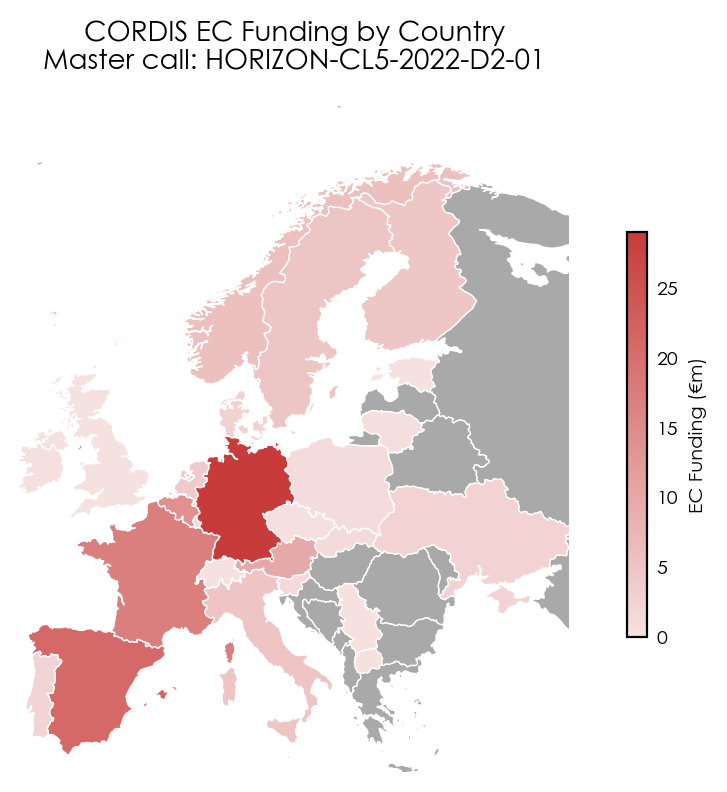

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot countries with no data in light grey
gdf[gdf['total_funding'].isna()].plot(ax=ax, color="#A9A9A9", edgecolor='white', linewidth=0.5)

# Choropleth for countries with data
gdf[gdf['total_funding'].notna()].plot(
    ax=ax, column='funding_m', cmap=tg_cmap, edgecolor='white',
    linewidth=0.5, legend=True,
    legend_kwds={'label': 'EC Funding (\u20acm)', 'shrink': 0.6})

ax.set_xlim(-10, 40)
ax.set_ylim(35, 75)

ax.set_title(f'CORDIS EC Funding by Country\nMaster call: {MASTER_CALL}')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 6. Annotated Map with Funding Amounts

Add funding labels to each country that received funding.

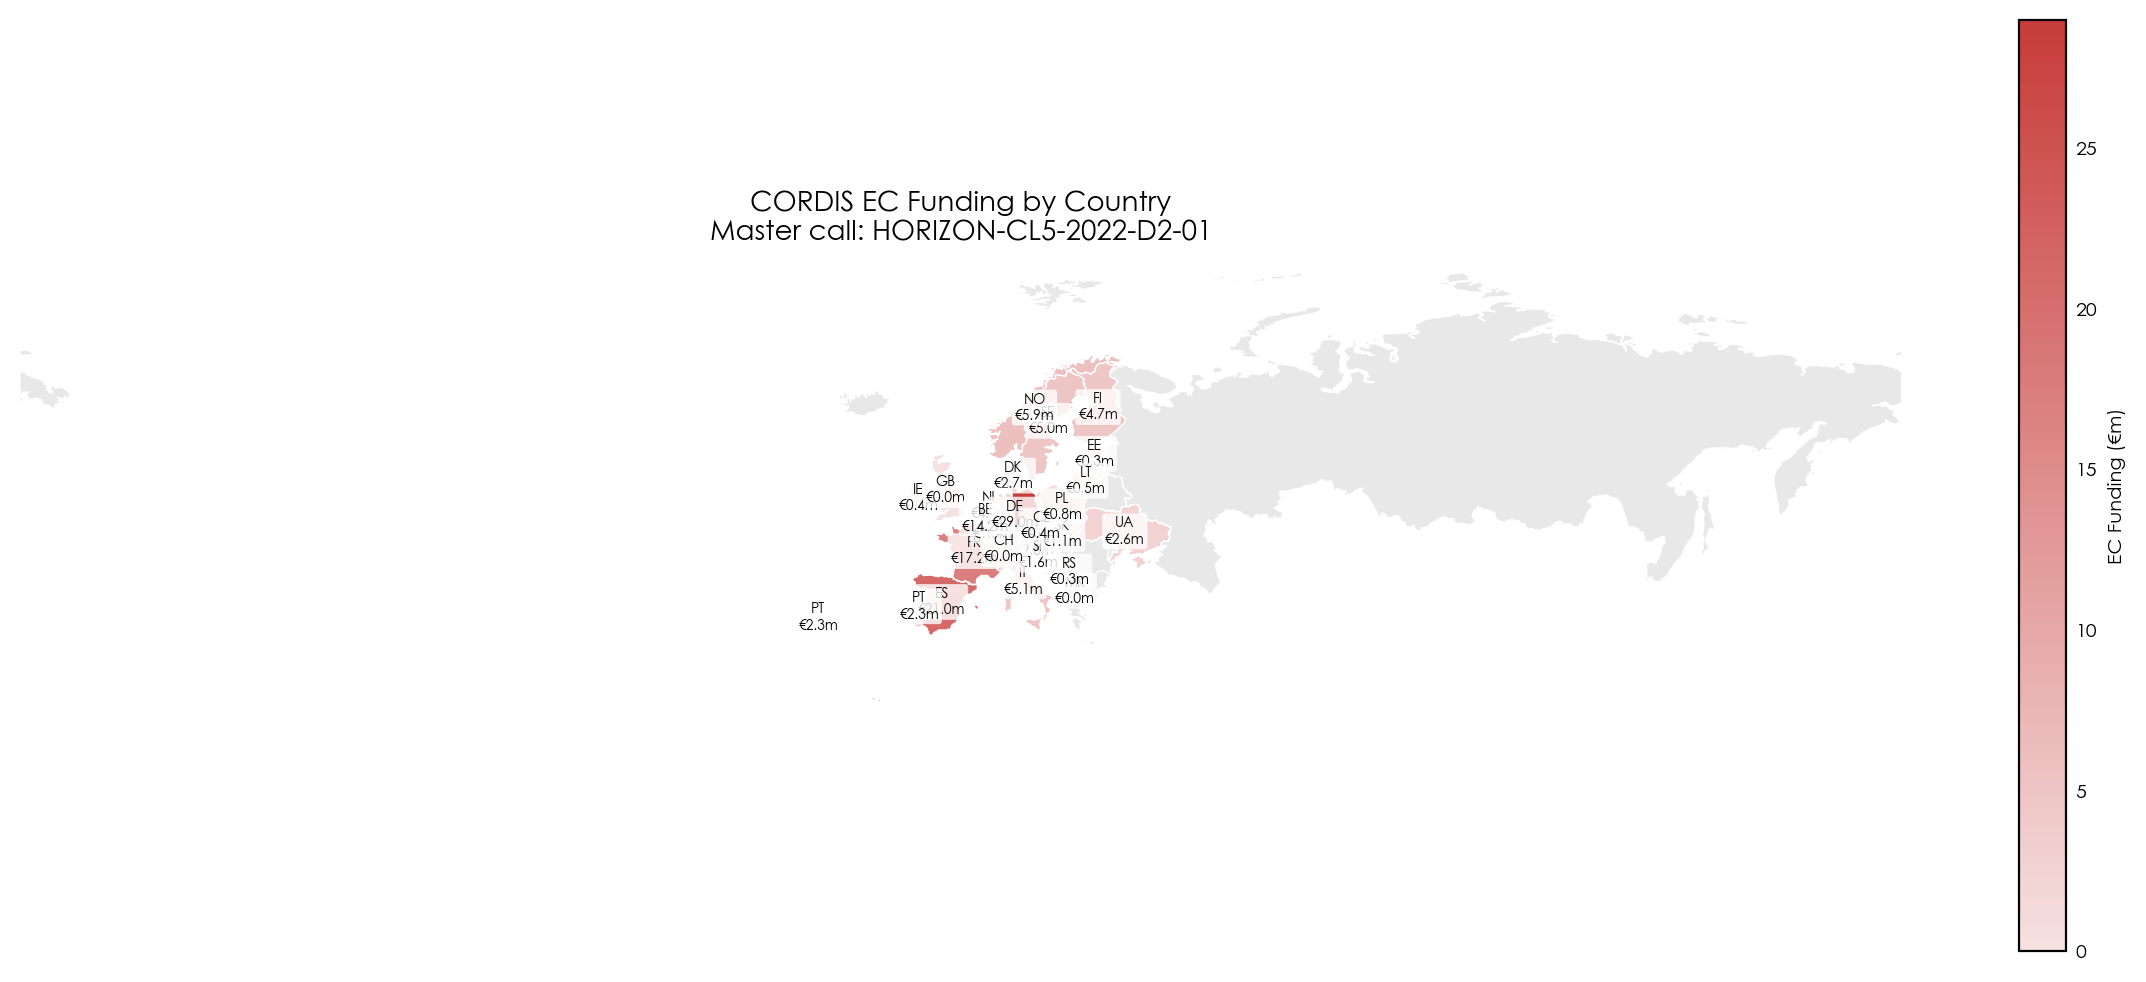

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

gdf[gdf['total_funding'].isna()].plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.5)
gdf[gdf['total_funding'].notna()].plot(
    ax=ax, column='funding_m', cmap=tg_cmap, edgecolor='white',
    linewidth=0.5, legend=True,
    legend_kwds={'label': 'EC Funding (\u20acm)', 'shrink': 0.6})

# Annotate countries that have funding data
for _, row in gdf[gdf['total_funding'].notna()].iterrows():
    centroid = row.geometry.centroid
    ax.annotate(f"{row['iso_3166_1_']}\n\u20ac{row['funding_m']:.1f}m",
                xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.8, edgecolor='none'))

ax.set_title(f'CORDIS EC Funding by Country\nMaster call: {MASTER_CALL}')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Number of Organisations per Country

Instead of funding, colour by how many unique organisations participated.

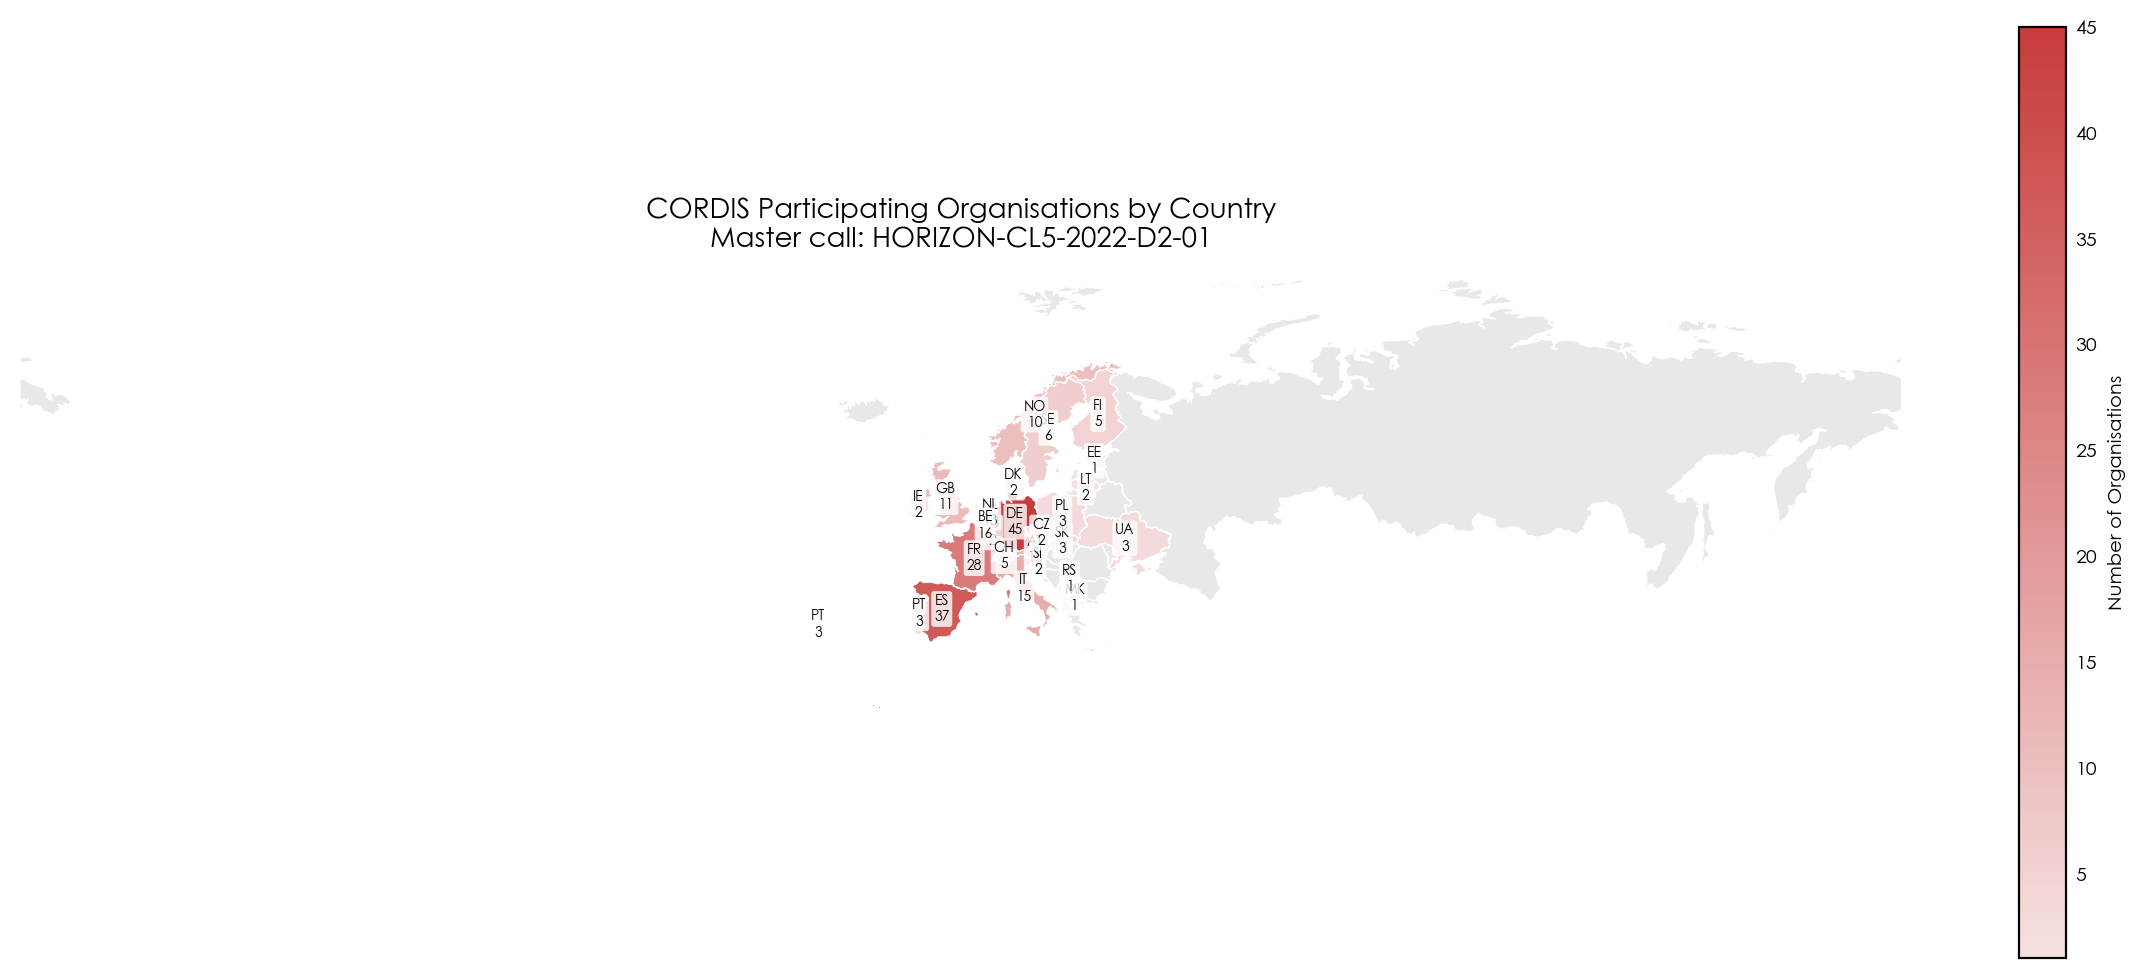

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

gdf[gdf['num_orgs'].isna()].plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.5)
gdf[gdf['num_orgs'].notna()].plot(
    ax=ax, column='num_orgs', cmap=tg_cmap, edgecolor='white',
    linewidth=0.5, legend=True,
    legend_kwds={'label': 'Number of Organisations', 'shrink': 0.6})

for _, row in gdf[gdf['num_orgs'].notna()].iterrows():
    centroid = row.geometry.centroid
    ax.annotate(f"{row['iso_3166_1_']}\n{int(row['num_orgs'])}",
                xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.8, edgecolor='none'))

ax.set_title(f'CORDIS Participating Organisations by Country\nMaster call: {MASTER_CALL}')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 8. Side-by-Side: Funding vs. Number of Orgs

Compare the two metrics to see if funding concentration matches organisation distribution.

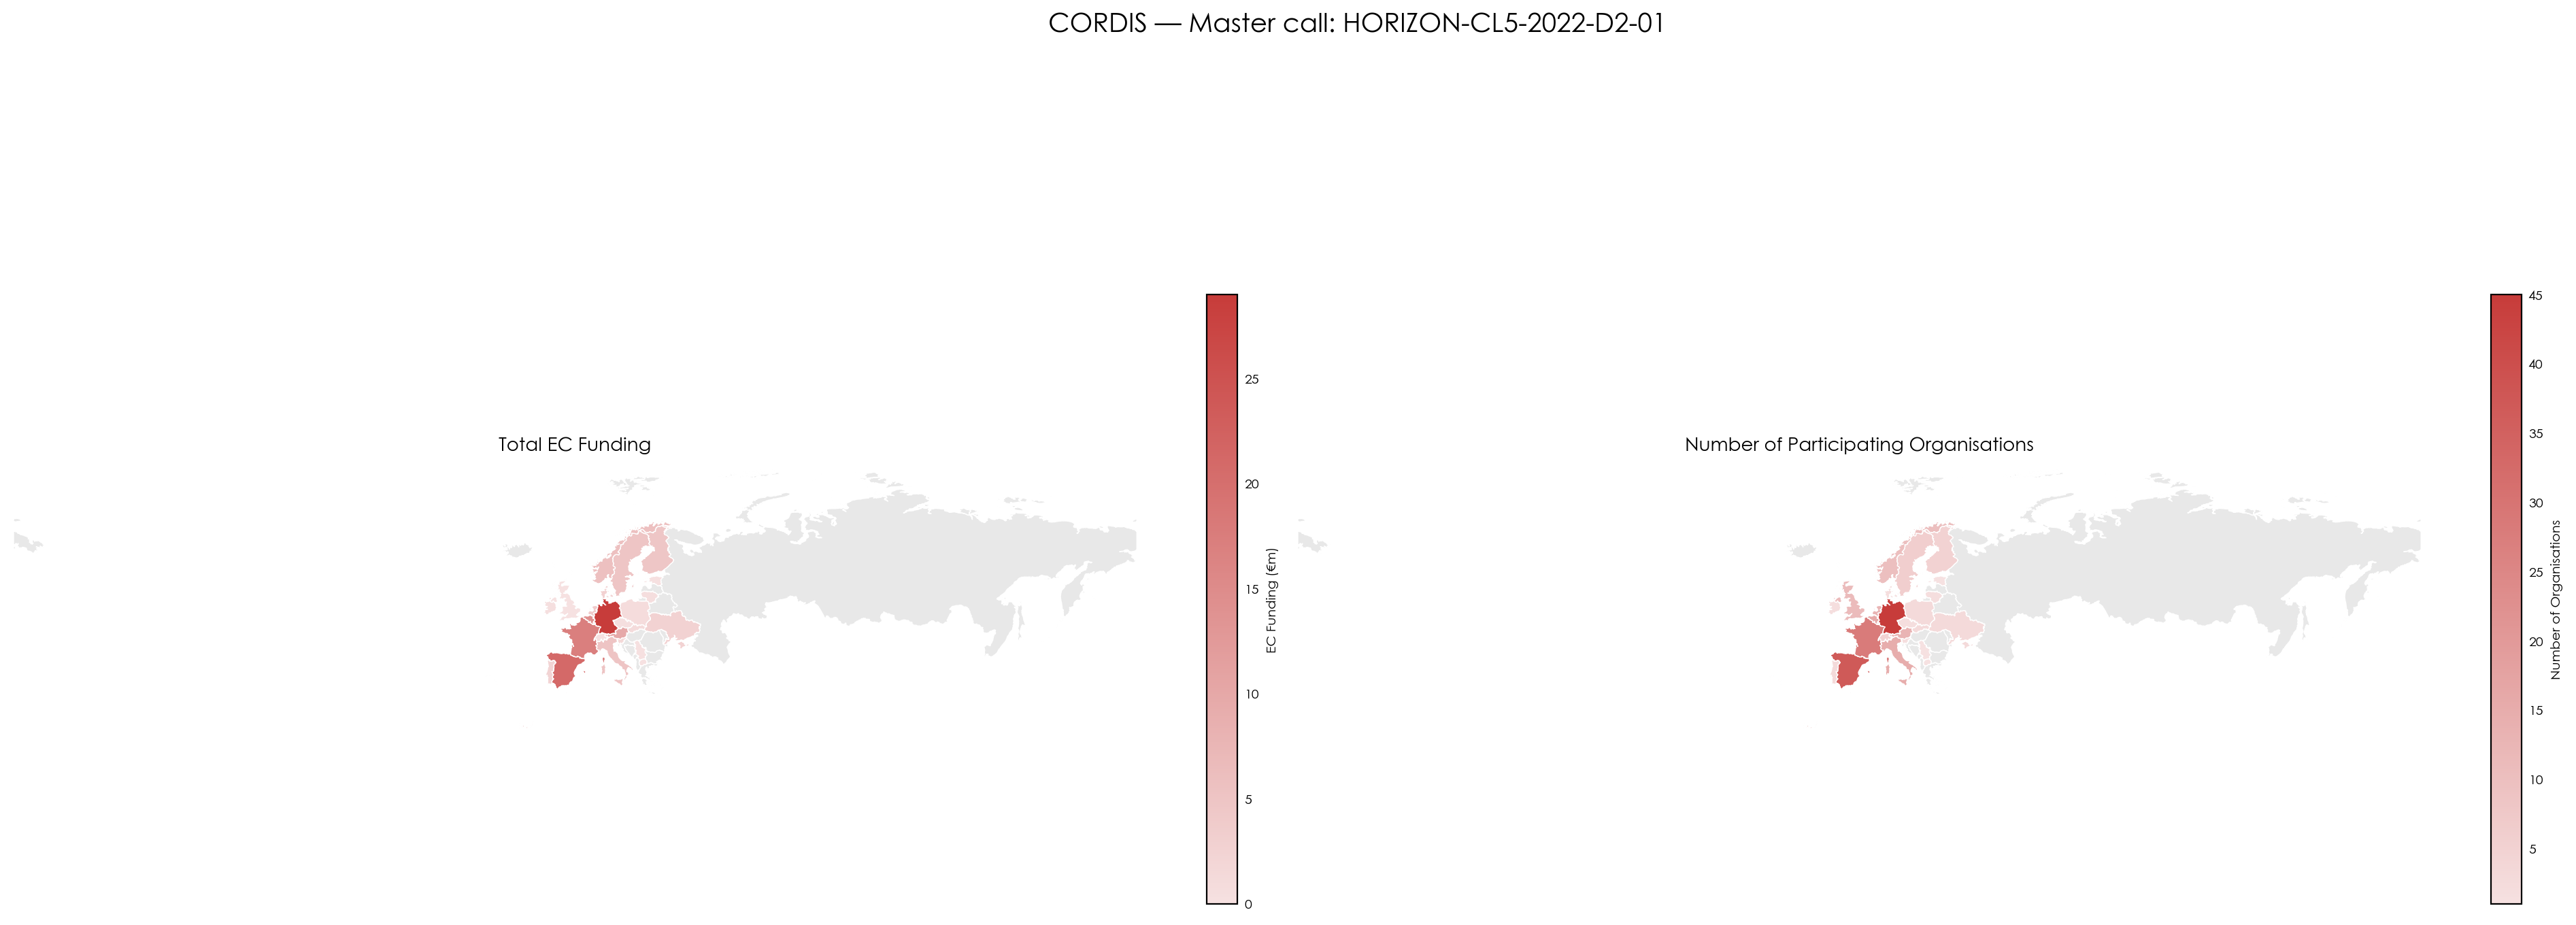

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

has_data = gdf['total_funding'].notna()
no_data = ~has_data

# Left: Funding
gdf[no_data].plot(ax=ax1, color='#e8e8e8', edgecolor='white', linewidth=0.5)
gdf[has_data].plot(ax=ax1, column='funding_m', cmap=tg_cmap, edgecolor='white',
                   linewidth=0.5, legend=True,
                   legend_kwds={'label': 'EC Funding (\u20acm)', 'shrink': 0.6})
ax1.set_title('Total EC Funding')
ax1.axis('off')

# Right: Number of orgs
gdf[no_data].plot(ax=ax2, color='#e8e8e8', edgecolor='white', linewidth=0.5)
gdf[has_data].plot(ax=ax2, column='num_orgs', cmap=tg_cmap, edgecolor='white',
                   linewidth=0.5, legend=True,
                   legend_kwds={'label': 'Number of Organisations', 'shrink': 0.6})
ax2.set_title('Number of Participating Organisations')
ax2.axis('off')

fig.suptitle(f'CORDIS — Master call: {MASTER_CALL}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Adjustable Label Positions

Store centroid positions in the DataFrame so you can nudge individual labels.

In [13]:
# Create editable label positions from centroids
gdf['label_x'] = gdf.geometry.centroid.x
gdf['label_y'] = gdf.geometry.centroid.y

# Uncomment and tweak to nudge specific labels, e.g.:
# gdf.loc[gdf['iso_3166_1_'] == 'NO', 'label_x'] += 3.0
# gdf.loc[gdf['iso_3166_1_'] == 'FR', 'label_y'] -= 0.5

gdf[gdf['total_funding'].notna()][['name', 'iso_3166_1_', 'label_x', 'label_y', 'funding_m']]

/var/folders/j9/h0b6mmmn4bvbwj0wqc2fywh40000gp/T/ipykernel_94392/3403542917.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['label_x'] = gdf.geometry.centroid.x
/var/folders/j9/h0b6mmmn4bvbwj0wqc2fywh40000gp/T/ipykernel_94392/3403542917.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['label_y'] = gdf.geometry.centroid.y


,name,iso_3166_1_,label_x,label_y,funding_m
1,France,FR,2.551955,46.564502,17.176716
2,Italy,IT,12.071743,42.795782,5.137450
4,Estonia,EE,25.527616,58.674136,0.272000
6,Ukraine,UA,31.387115,49.017088,2.624274
7,Denmark,DK,10.046298,55.963398,2.744148
8,Luxembourg,LU,6.087814,49.770630,1.330607
14,Austria,AT,14.140193,47.592903,9.775700
15,Slovenia,SI,14.826537,46.123564,1.561901
16,The former Yugoslav Republic of Macedonia,MK,21.697476,41.599682,0.000000
18,Ireland,IE,-8.150579,53.176382,0.408214


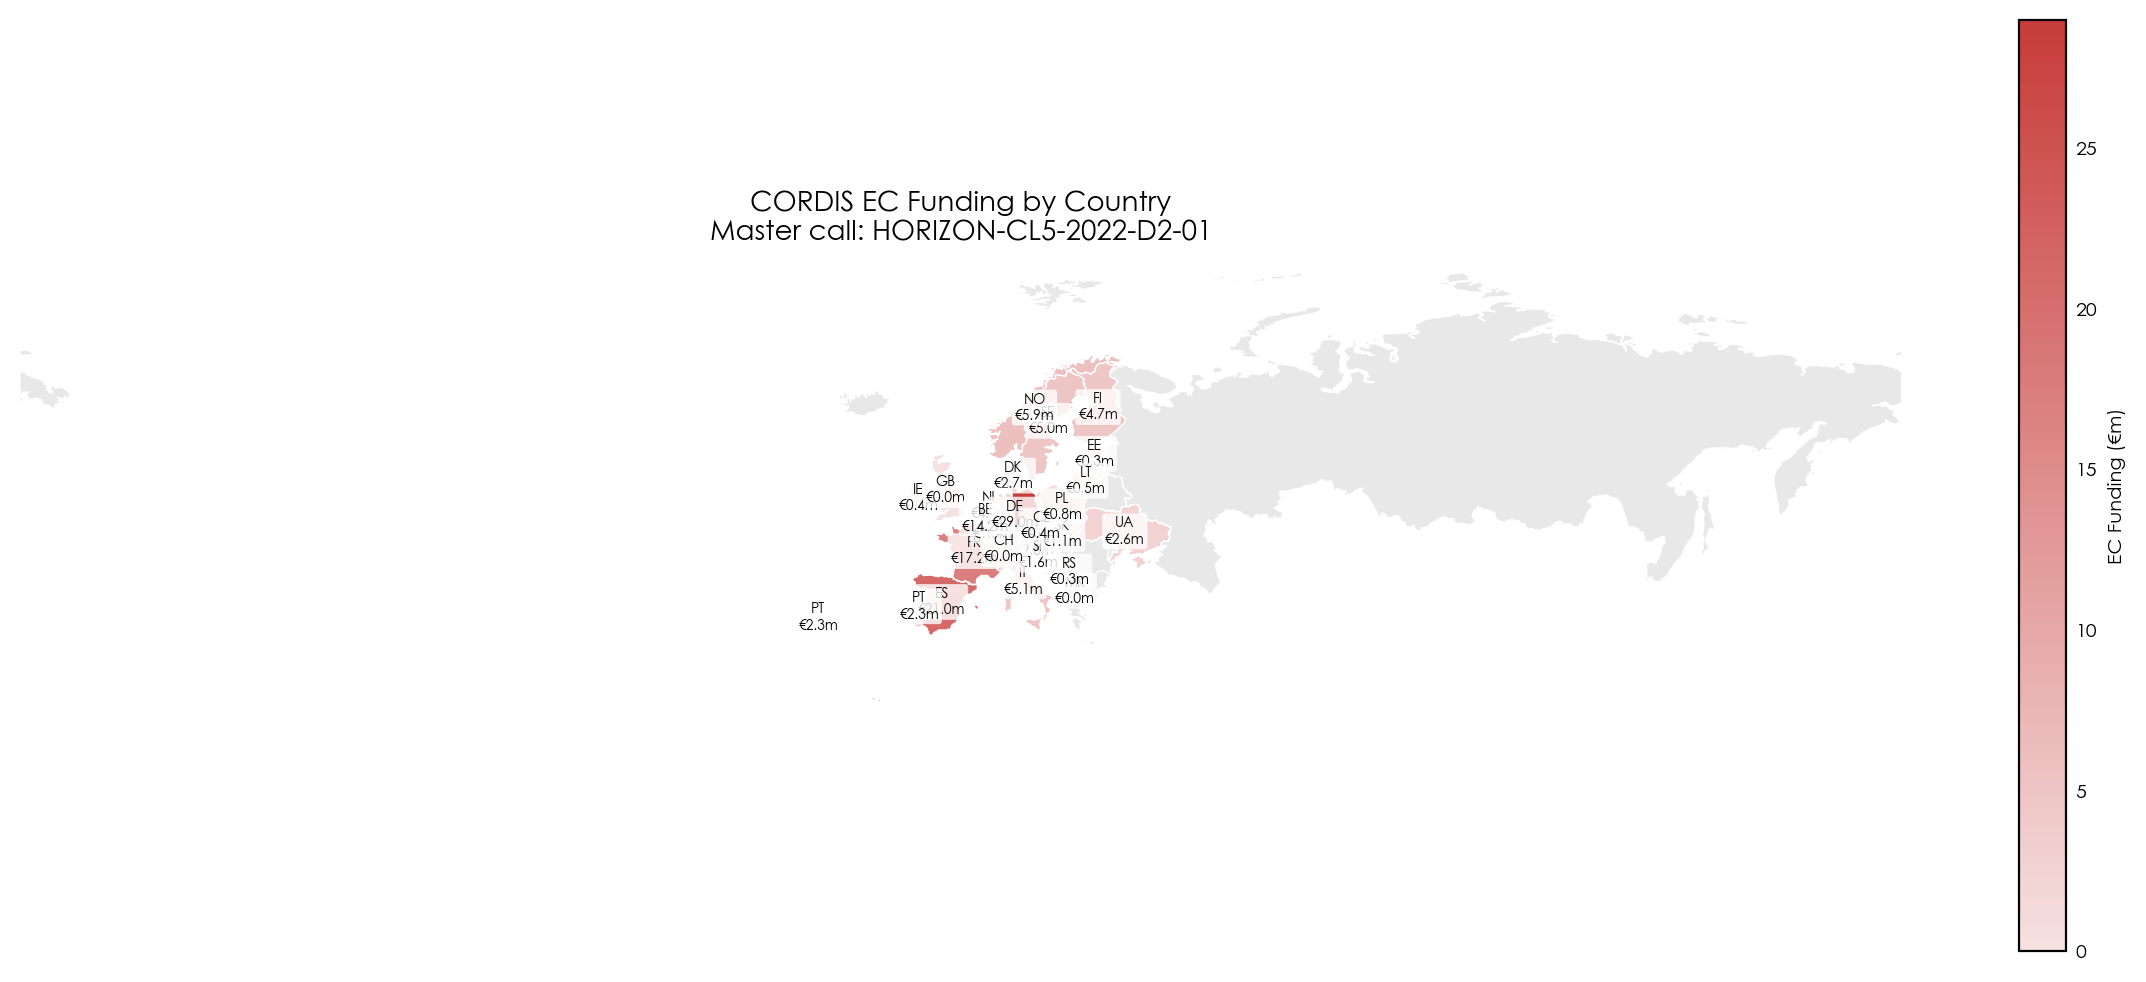

In [14]:
# Final map using adjustable label positions
fig, ax = plt.subplots(figsize=(12, 8))

gdf[gdf['total_funding'].isna()].plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.5)
gdf[gdf['total_funding'].notna()].plot(
    ax=ax, column='funding_m', cmap=tg_cmap, edgecolor='white',
    linewidth=0.5, legend=True,
    legend_kwds={'label': 'EC Funding (\u20acm)', 'shrink': 0.6})

for _, row in gdf[gdf['total_funding'].notna()].iterrows():
    ax.annotate(f"{row['iso_3166_1_']}\n\u20ac{row['funding_m']:.1f}m",
                xy=(row['label_x'], row['label_y']),
                ha='center', va='center', fontsize=5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.8, edgecolor='none'))

ax.set_title(f'CORDIS EC Funding by Country\nMaster call: {MASTER_CALL}')
ax.axis('off')
plt.tight_layout()
plt.show()